<a href="https://colab.research.google.com/github/anuj0407/Review_Mathematics_02_06_2026/blob/main/Supply_chain_risk_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install faker -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 33.9 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Loading Dataset :
File name : supply_chain_hormuz_crisis_700.csv




In [ ]:
df = pd.read_csv("/content/supply_chain_hormuz_crisis_700.csv")
df.head()

,Shipment_ID,Supplier_ID,Country,Product_Type,Monthly_Demand_Tons,Shipment_Volume_Tons,Route_Risk_Score,Historical_Delay_Days,Fuel_Price_USD,Political_Risk_Index,Port_Congestion_Index,Inventory_Days,Supplier_Reliability,Alternative_Supplier_Count,Transit_Time_Days,Delay_Probability,Current_Delay_Days,Freight_Cost_USD,Revenue_Impact_USD,Disruption_Event
0,SHP0001,SUP039,Oman,Electronics,38384,7088,4.33,15,69.90,4.37,3.96,64,0.86,9,26,0.33,6,183213.04,345791.65,0
1,SHP0002,SUP029,Iraq,Crude Oil,17393,9116,4.37,17,85.15,8.98,1.47,35,0.54,3,8,0.48,9,261957.42,560978.97,0
2,SHP0003,SUP015,Oman,Electronics,11617,6804,5.27,15,76.51,2.36,5.05,15,0.68,0,15,0.43,18,172895.04,803773.25,0
3,SHP0004,SUP043,Germany,Crude Oil,39520,7845,5.00,9,79.95,2.37,3.29,6,0.92,7,12,0.19,8,240963.11,627069.58,0
4,SHP0005,SUP008,Iraq,LNG,10852,13416,9.95,17,96.80,3.96,4.17,31,0.61,1,13,0.48,4,314719.51,767940.98,0


### Sakshi

Task 1: Supply Dependency Matrix Analysis (Linear Algebra)
Objective
Determine which countries are most dependent on suppliers and identify concentration risks.


Requirements
Create a Supplier-Country Matrix:
Rows = Supplier_ID
Columns = Country
Values = Total Shipment_Volume_Tons

In [ ]:
supplier_country_mat=df.pivot_table(index='Supplier_ID',columns='Country',values='Shipment_Volume_Tons',aggfunc='sum')
supplier_country_mat

Country,China,Germany,India,Iraq,Kuwait,Oman,Qatar,Saudi Arabia,Singapore,UAE
Supplier_ID,,,,,,,,,,
SUP001,12232.0,NaN,3821.0,13105.0,16159.0,NaN,20154.0,23905.0,NaN,11256.0
SUP002,2894.0,6862.0,NaN,2590.0,4121.0,51234.0,10390.0,8672.0,22080.0,1110.0
SUP003,4190.0,11001.0,NaN,11151.0,11907.0,17218.0,10312.0,33343.0,NaN,14360.0
SUP004,NaN,8865.0,NaN,14447.0,5608.0,11632.0,9035.0,21438.0,7019.0,29734.0
SUP005,NaN,11767.0,29699.0,NaN,NaN,19277.0,10987.0,20763.0,NaN,NaN
SUP006,NaN,NaN,NaN,NaN,NaN,26164.0,9777.0,29869.0,17331.0,13076.0
SUP007,12966.0,NaN,33462.0,15511.0,NaN,14708.0,4993.0,14635.0,NaN,9598.0
SUP008,10771.0,9421.0,10558.0,27481.0,15894.0,13126.0,13468.0,NaN,NaN,14225.0
SUP009,20681.0,507.0,9905.0,21298.0,NaN,4025.0,3747.0,4250.0,13841.0,21722.0


In [ ]:
supplier_country_mat.shape

(50, 10)

In [ ]:
clean_mat=supplier_country_mat.fillna(0)
clean_mat.shape

(50, 10)

Perform the following operations using NumPy:
Matrix Transpose
Matrix Multiplication
Dot Product Analysis


In [ ]:
matrix_tans=clean_mat.T
matrix_tans


Supplier_ID,SUP001,SUP002,SUP003,SUP004,SUP005,SUP006,SUP007,SUP008,SUP009,SUP010,...,SUP041,SUP042,SUP043,SUP044,SUP045,SUP046,SUP047,SUP048,SUP049,SUP050
Country,,,,,,,,,,,,,,,,,,,,,
China,12232.0,2894.0,4190.0,0.0,0.0,0.0,12966.0,10771.0,20681.0,9460.0,...,0.0,842.0,9111.0,13263.0,13566.0,3024.0,6327.0,14640.0,17002.0,0.0
Germany,0.0,6862.0,11001.0,8865.0,11767.0,0.0,0.0,9421.0,507.0,11911.0,...,0.0,9285.0,7845.0,19934.0,29373.0,0.0,1227.0,0.0,13640.0,19933.0
India,3821.0,0.0,0.0,0.0,29699.0,0.0,33462.0,10558.0,9905.0,0.0,...,12481.0,1087.0,0.0,9253.0,13228.0,8013.0,0.0,0.0,37565.0,18181.0
Iraq,13105.0,2590.0,11151.0,14447.0,0.0,0.0,15511.0,27481.0,21298.0,9601.0,...,19158.0,20921.0,0.0,25078.0,1270.0,7153.0,16213.0,10158.0,10950.0,25130.0
Kuwait,16159.0,4121.0,11907.0,5608.0,0.0,0.0,0.0,15894.0,0.0,26553.0,...,27155.0,0.0,0.0,4878.0,0.0,0.0,14703.0,33544.0,0.0,7101.0
Oman,0.0,51234.0,17218.0,11632.0,19277.0,26164.0,14708.0,13126.0,4025.0,14191.0,...,0.0,11746.0,3767.0,20991.0,12138.0,14135.0,7734.0,2613.0,23523.0,0.0
Qatar,20154.0,10390.0,10312.0,9035.0,10987.0,9777.0,4993.0,13468.0,3747.0,0.0,...,14716.0,14718.0,10588.0,12141.0,48442.0,10277.0,5487.0,17954.0,12836.0,5913.0
Saudi Arabia,23905.0,8672.0,33343.0,21438.0,20763.0,29869.0,14635.0,0.0,4250.0,0.0,...,0.0,15881.0,7216.0,942.0,0.0,0.0,8193.0,38828.0,19828.0,14351.0
Singapore,0.0,22080.0,0.0,7019.0,0.0,17331.0,0.0,0.0,13841.0,0.0,...,7059.0,11628.0,0.0,597.0,14191.0,11919.0,0.0,14414.0,11285.0,0.0


In [ ]:
mat_multiply=np.matmul(clean_mat,matrix_tans)
mat_multiply

Supplier_ID,SUP001,SUP002,SUP003,SUP004,SUP005,SUP006,SUP007,SUP008,SUP009,SUP010,...,SUP041,SUP042,SUP043,SUP044,SUP045,SUP046,SUP047,SUP048,SUP049,SUP050
Supplier_ID,,,,,,,,,,,,,,,,,,,,,
SUP001,1.701406e+09,5.651310e+08,1.556320e+09,1.309200e+09,8.312514e+08,1.058248e+09,1.048244e+09,1.220613e+09,9.915434e+08,6.706058e+08,...,1.191960e+09,9.648844e+08,5.249795e+08,1.004650e+09,1.209427e+09,3.684700e+08,8.603843e+08,2.361774e+09,1.405331e+09,9.757746e+08
SUP002,5.651310e+08,3.375990e+09,1.459943e+09,1.185082e+09,1.362595e+09,2.098276e+09,1.020693e+09,1.060713e+09,7.302165e+08,9.704637e+08,...,4.858502e+08,1.269517e+09,4.485107e+08,1.496228e+09,1.682635e+09,1.121420e+09,6.562291e+08,1.203756e+09,1.948345e+09,4.170181e+08
SUP003,1.556320e+09,1.459943e+09,2.125462e+09,1.760633e+09,1.266959e+09,1.735006e+09,1.157823e+09,1.213618e+09,8.913021e+08,8.382383e+08,...,8.900584e+08,1.222497e+09,5.743928e+08,1.299511e+09,1.102662e+09,4.417865e+08,8.925967e+08,2.376289e+09,1.768534e+09,1.123539e+09
SUP004,1.309200e+09,1.185082e+09,1.760633e+09,1.928653e+09,8.729293e+08,1.543455e+09,1.039415e+09,1.267000e+09,1.227003e+09,5.582756e+08,...,1.028467e+09,1.076238e+09,4.367496e+08,1.294320e+09,9.572086e+08,4.442699e+08,7.127333e+08,2.035623e+09,1.642250e+09,9.406623e+08
SUP005,8.312514e+08,1.362595e+09,1.266959e+09,8.729293e+08,1.943912e+09,1.231953e+09,1.636039e+09,8.254218e+08,5.071354e+08,4.137166e+08,...,5.323579e+08,8.594109e+08,4.310847e+08,1.066964e+09,1.504707e+09,6.233719e+08,3.939234e+08,1.053817e+09,2.282316e+09,1.137445e+09
SUP006,1.058248e+09,2.098276e+09,1.735006e+09,1.543455e+09,1.231953e+09,2.143647e+09,9.962729e+08,6.611114e+08,7.928030e+08,3.712933e+08,...,4.495565e+08,1.127095e+09,4.497280e+08,8.601811e+08,1.037140e+09,6.768746e+08,5.314964e+08,1.906146e+09,1.735142e+09,4.864614e+08
SUP007,1.048244e+09,1.020693e+09,1.157823e+09,1.039415e+09,1.636039e+09,9.962729e+08,2.075974e+09,1.316041e+09,1.278539e+09,4.803007e+08,...,9.228495e+08,8.504618e+08,3.555830e+08,1.366601e+09,1.058628e+09,6.775010e+08,6.171622e+08,1.229179e+09,2.499018e+09,1.237715e+09
SUP008,1.220613e+09,1.060713e+09,1.213618e+09,1.267000e+09,8.254218e+08,6.611114e+08,1.316041e+09,1.880095e+09,1.329691e+09,1.086257e+09,...,1.487501e+09,1.035350e+09,3.990238e+08,1.801390e+09,1.409145e+09,6.376910e+08,9.678477e+08,1.520974e+09,1.715296e+09,1.262841e+09
SUP009,9.915434e+08,7.302165e+08,8.913021e+08,1.227003e+09,5.071354e+08,7.928030e+08,1.278539e+09,1.329691e+09,1.691396e+09,4.632820e+08,...,9.890600e+08,8.093265e+08,3.312546e+08,1.307881e+09,8.803076e+08,5.546249e+08,6.144182e+08,1.381185e+09,1.689886e+09,8.085553e+08


In [ ]:
dot_prod=np.dot(clean_mat,matrix_tans)
dot_prod

array([[1.70140645e+09, 5.65130977e+08, 1.55631977e+09, ...,
        2.36177377e+09, 1.40533136e+09, 9.75774567e+08],
       [5.65130977e+08, 3.37598996e+09, 1.45994335e+09, ...,
        1.20375588e+09, 1.94834463e+09, 4.17018109e+08],
       [1.55631977e+09, 1.45994335e+09, 2.12546167e+09, ...,
        2.37628879e+09, 1.76853384e+09, 1.12353942e+09],
       ...,
       [2.36177377e+09, 1.20375588e+09, 2.37628879e+09, ...,
        3.86068234e+09, 1.88957746e+09, 1.15684911e+09],
       [1.40533136e+09, 1.94834463e+09, 1.76853384e+09, ...,
        1.88957746e+09, 3.49381609e+09, 1.59047978e+09],
       [9.75774567e+08, 4.17018109e+08, 1.12353942e+09, ...,
        1.15684911e+09, 1.59047978e+09, 1.65072912e+09]])

Calculate:
Top 5 countries with the highest dependency on suppliers
Top 5 suppliers contributing the highest shipment volumes


In [ ]:
top_country=clean_mat.sum().sort_values(ascending=False)
top_country.head()

,0
Country,
Saudi Arabia,697434.0
Iraq,631566.0
Oman,583440.0
Qatar,555237.0
Germany,547346.0


In [ ]:
top_5_supplier=clean_mat.sum(axis=1).sort_values(ascending=False)
top_5_supplier.head()

,0
Supplier_ID,
SUP033,212861.0
SUP024,183505.0
SUP039,182399.0
SUP035,162923.0
SUP049,162411.0


Visualization 1
Distribution of Current Delay Days


Text(0, 0.5, 'count')

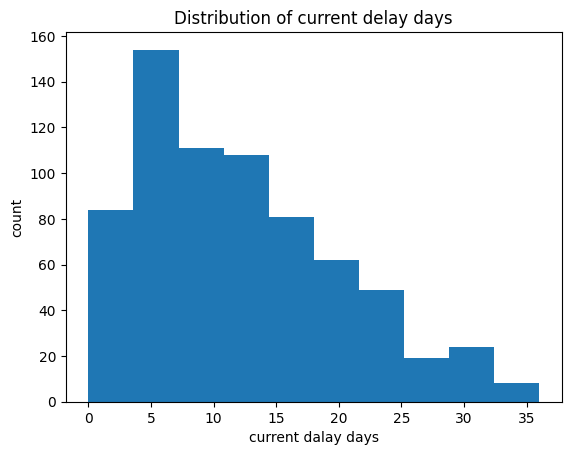

In [ ]:
plt.hist(df['Current_Delay_Days'])
plt.title('Distribution of current delay days')
plt.xlabel('current dalay days')
plt.ylabel('count')

### Nisha

#Task 2: Shipment Risk Exposure Model (Linear Algebra)
Objective
Develop a risk scoring model for all shipments using matrix operations.

Create a Risk Matrix using the three risk factors.

In [ ]:
risk_matrix=df[[
    'Route_Risk_Score',
    'Political_Risk_Index',
    'Port_Congestion_Index']
]
risk_matrix.head()


,Route_Risk_Score,Political_Risk_Index,Port_Congestion_Index
0,4.33,4.37,3.96
1,4.37,8.98,1.47
2,5.27,2.36,5.05
3,5.00,2.37,3.29
4,9.95,3.96,4.17


Apply matrix multiplication using the weight vector.

In [ ]:
weights = np.array([0.40,0.35,0.25])
df['Risk_Score'] = np.dot(risk_matrix,weights)
df['Risk_Score'].head()

,Risk_Score
0,4.2515
1,5.2585
2,4.1965
3,3.6520
4,6.4085


Identify:
Top 10 highest-risk shipments

In [ ]:
top_highest_risk_shipments = df[['Shipment_ID','Risk_Score']].sort_values(by='Risk_Score',ascending=False).head(10)
top_highest_risk_shipments

,Shipment_ID,Risk_Score
654,SHP0655,9.5635
57,SHP0058,9.1750
499,SHP0500,9.1675
404,SHP0405,9.1135
240,SHP0241,8.8405
284,SHP0285,8.8240
43,SHP0044,8.7995
257,SHP0258,8.7760
291,SHP0292,8.7450
569,SHP0570,8.7295


Identfy:
Average risk score by country

In [ ]:
country_risk_score = df.groupby('Country')['Risk_Score'].mean().sort_values(ascending=False)
country_risk_score

,Risk_Score
Country,
Oman,5.864184
India,5.722975
Iraq,5.719850
Qatar,5.695171
Kuwait,5.620407
Germany,5.462890
Saudi Arabia,5.436689
UAE,5.288652
Singapore,5.183639


Visualization 2
Shipment Risk Score Distribution

Text(0, 0.5, 'Number of Shipments')

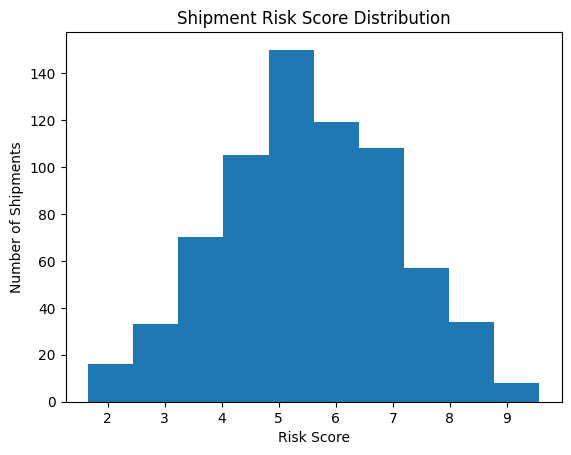

In [ ]:
plt.hist(df['Risk_Score'])
plt.title('Shipment Risk Score Distribution')
plt.xlabel('Risk Score')
plt.ylabel('Number of Shipments')

### Mradul Sharma

## Task 3: Delay and Disruption Statistical Analysis
Objective

Analyze shipment delays and disruption patterns using Probability and Statistics.

Requirements

Calculate the following for:
Disruption_Event = 1
Disruption_Event = 0

Metrics:

Mean
Median
Variance
Standard Deviation

Additional Analysis

Create:
Correlation Matrix
Covariance Matrix

Using the following variables:

Route_Risk_Score
Political_Risk_Index
Port_Congestion_Index
Current_Delay_Days
Delay_Probability


In [ ]:
from faker import Faker
fake = Faker()

In [ ]:
df["Disruption_Event"] = [fake.random_element(elements=(0, 1)) for i in range(len(df))]
df

,Shipment_ID,Supplier_ID,Country,Product_Type,Monthly_Demand_Tons,Shipment_Volume_Tons,Route_Risk_Score,Historical_Delay_Days,Fuel_Price_USD,Political_Risk_Index,...,Inventory_Days,Supplier_Reliability,Alternative_Supplier_Count,Transit_Time_Days,Delay_Probability,Current_Delay_Days,Freight_Cost_USD,Revenue_Impact_USD,Disruption_Event,Risk_Score
0,SHP0001,SUP039,Oman,Electronics,38384,7088,4.33,15,69.90,4.37,...,64,0.86,9,26,0.33,6,183213.04,345791.65,1,4.2515
1,SHP0002,SUP029,Iraq,Crude Oil,17393,9116,4.37,17,85.15,8.98,...,35,0.54,3,8,0.48,9,261957.42,560978.97,0,5.2585
2,SHP0003,SUP015,Oman,Electronics,11617,6804,5.27,15,76.51,2.36,...,15,0.68,0,15,0.43,18,172895.04,803773.25,0,4.1965
3,SHP0004,SUP043,Germany,Crude Oil,39520,7845,5.00,9,79.95,2.37,...,6,0.92,7,12,0.19,8,240963.11,627069.58,0,3.6520
4,SHP0005,SUP008,Iraq,LNG,10852,13416,9.95,17,96.80,3.96,...,31,0.61,1,13,0.48,4,314719.51,767940.98,1,6.4085
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
695,SHP0696,SUP013,Singapore,Electronics,27928,13329,9.20,18,97.98,1.68,...,81,0.71,0,16,0.58,17,297468.99,1148921.88,1,5.7955
696,SHP0697,SUP028,India,Electronics,19322,4509,4.19,7,113.19,4.38,...,41,0.76,6,6,0.42,20,119168.92,513201.57,0,4.3065
697,SHP0698,SUP049,Saudi Arabia,Fertilizer,23360,7128,4.82,8,102.21,8.38,...,85,0.97,2,42,0.62,18,193551.45,813671.04,1,7.2810
698,SHP0699,SUP025,China,Crude Oil,30055,2669,2.94,16,91.96,1.06,...,25,0.63,10,9,0.25,9,121059.31,252786.92,0,2.4120


In [ ]:
counts_values = df["Disruption_Event"].value_counts()
counts_values

,count
Disruption_Event,
1,357
0,343


In [ ]:
variables_matrix=df[['Route_Risk_Score','Political_Risk_Index','Port_Congestion_Index','Current_Delay_Days','Delay_Probability']]
variables_matrix

,Route_Risk_Score,Political_Risk_Index,Port_Congestion_Index,Current_Delay_Days,Delay_Probability
0,4.33,4.37,3.96,6,0.33
1,4.37,8.98,1.47,9,0.48
2,5.27,2.36,5.05,18,0.43
3,5.00,2.37,3.29,8,0.19
4,9.95,3.96,4.17,4,0.48
...,...,...,...,...,...
695,9.20,1.68,6.11,17,0.58
696,4.19,4.38,4.39,20,0.42
697,4.82,8.38,9.68,18,0.62
698,2.94,1.06,3.46,9,0.25


In [ ]:
#Mean
mean_values = variables_matrix.mean()
mean_values

,0
Route_Risk_Score,5.616357
Political_Risk_Index,5.500129
Port_Congestion_Index,5.367114
Current_Delay_Days,12.174286
Delay_Probability,0.469457


In [ ]:
#Median
median_values = variables_matrix.median()
median_values

,0
Route_Risk_Score,5.800
Political_Risk_Index,5.505
Port_Congestion_Index,5.295
Current_Delay_Days,11.000
Delay_Probability,0.460


In [ ]:
#Variance
variance_values = variables_matrix.var()
variance_values

,0
Route_Risk_Score,6.804401
Political_Risk_Index,6.523422
Port_Congestion_Index,7.156212
Current_Delay_Days,61.892328
Delay_Probability,0.023915


In [ ]:
#Standard Deviation
std_values = variables_matrix.std()
std_values

,0
Route_Risk_Score,2.608525
Political_Risk_Index,2.554099
Port_Congestion_Index,2.675110
Current_Delay_Days,7.867168
Delay_Probability,0.154644


In [ ]:
#Correlation Matrix
correlation_matrix = variables_matrix.corr()
correlation_matrix

,Route_Risk_Score,Political_Risk_Index,Port_Congestion_Index,Current_Delay_Days,Delay_Probability
Route_Risk_Score,1.000000,-0.017301,0.023497,0.281699,0.592717
Political_Risk_Index,-0.017301,1.000000,0.009180,0.236165,0.495961
Port_Congestion_Index,0.023497,0.009180,1.000000,0.260854,0.365754
Current_Delay_Days,0.281699,0.236165,0.260854,1.000000,0.523825
Delay_Probability,0.592717,0.495961,0.365754,0.523825,1.000000


In [ ]:
corr_matrix=np.array(correlation_matrix)
corr_matrix

array([[ 1.        , -0.01730103,  0.02349667,  0.28169869,  0.59271688],
       [-0.01730103,  1.        ,  0.00918035,  0.23616489,  0.49596079],
       [ 0.02349667,  0.00918035,  1.        ,  0.26085353,  0.3657545 ],
       [ 0.28169869,  0.23616489,  0.26085353,  1.        ,  0.52382533],
       [ 0.59271688,  0.49596079,  0.3657545 ,  0.52382533,  1.        ]])

In [ ]:
#Covariance Matrix
covariance_matrix = variables_matrix.cov()
covariance_matrix

,Route_Risk_Score,Political_Risk_Index,Port_Congestion_Index,Current_Delay_Days,Delay_Probability
Route_Risk_Score,6.804401,-0.115267,0.163962,5.780936,0.239097
Political_Risk_Index,-0.115267,6.523422,0.062725,4.745385,0.195892
Port_Congestion_Index,0.163962,0.062725,7.156212,5.489803,0.151309
Current_Delay_Days,5.780936,4.745385,5.489803,61.892328,0.637291
Delay_Probability,0.239097,0.195892,0.151309,0.637291,0.023915


In [ ]:
cov_matrix=np.array(covariance_matrix)
cov_matrix

array([[ 6.80440059e+00, -1.15266913e-01,  1.63961862e-01,
         5.78093624e+00,  2.39097447e-01],
       [-1.15266913e-01,  6.52342187e+00,  6.27246920e-02,
         4.74538529e+00,  1.95892488e-01],
       [ 1.63961862e-01,  6.27246920e-02,  7.15621226e+00,
         5.48980266e+00,  1.51308732e-01],
       [ 5.78093624e+00,  4.74538529e+00,  5.48980266e+00,
         6.18923278e+01,  6.37290742e-01],
       [ 2.39097447e-01,  1.95892488e-01,  1.51308732e-01,
         6.37290742e-01,  2.39147263e-02]])

# Visualization 3



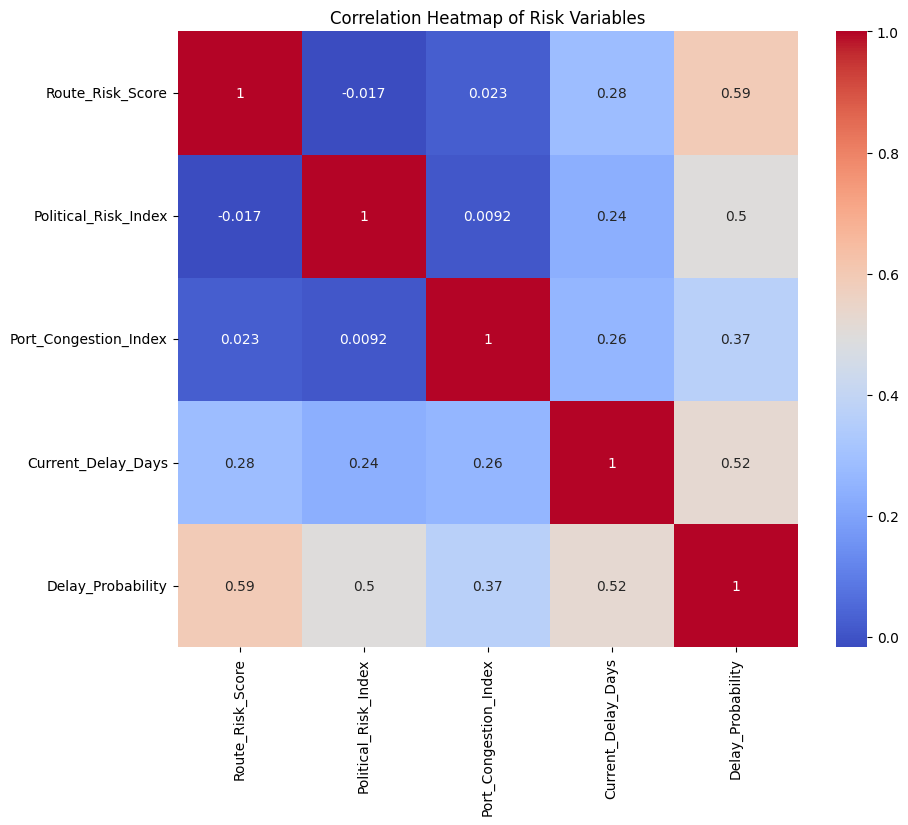

In [ ]:
#Correlation Heatmap of Risk Variables
plt.figure(figsize=(10,8))
sns.heatmap(correlation_matrix,annot=True,cmap='coolwarm')
plt.title('Correlation Heatmap of Risk Variables')
plt.show()

### Anuj


# Task 4: Inventory Stockout Risk Assessment
## Objective
Estimate inventory shortage risks caused by shipment delays.
## Business Rule
A shipment is considered at risk of stockout when:
Current_Delay_Days > Inventory_Days
### Requirements
1. Calculate:
    - Total stockout events
    - Percentage of shipments at risk
    - Probability of stockout



In [ ]:
# Total stockout events
total_stockout_events = df[df['Current_Delay_Days'] > df['Inventory_Days']].shape[0]
print("Total Stockout events :",total_stockout_events)

Total Stockout events : 60


In [ ]:
# Percentage of Shipments at risk
percentage = (total_stockout_events / len(df)) * 100
print("Percentage of shipments at risk :",percentage)

Percentage of shipments at risk : 8.571428571428571


In [ ]:
# Probability of Stockout
probability_of_stockout = total_stockout_events / len(df)
print("Probability of Stockout :",probability_of_stockout)

Probability of Stockout : 0.08571428571428572


2. Perform a Monte Carlo Simulation:
    - 1,000 iterations
    - Use Delay_Probability to simulate future delays


In [ ]:
np.random.seed(42)
iterations = 1000
simulated_stockouts_per_run = []
for i in range(iterations):
    draws = np.random.rand(len(df))
    shipments_failed = draws < df['Delay_Probability']
    simulated_stockouts_per_run.append(shipments_failed.sum())

simulation_result = np.array(simulated_stockouts_per_run)
print("Simulation result :", simulation_result)

Simulation result : [332 321 330 336 325 339 345 327 335 331 356 332 341 336 312 308 331 327
 331 341 312 330 331 308 304 327 309 335 321 317 329 306 301 316 327 324
 322 339 326 352 346 345 319 337 331 320 323 330 332 331 340 338 335 313
 338 318 345 324 342 317 328 347 348 343 314 340 331 330 330 348 338 332
 306 314 332 325 337 313 337 334 311 328 325 318 334 350 322 340 337 307
 331 336 337 326 312 317 316 334 316 299 343 326 319 339 311 329 354 326
 315 327 326 322 335 335 322 329 303 319 324 312 320 343 321 333 340 337
 341 327 344 335 309 341 308 353 345 334 338 317 328 333 343 331 331 329
 322 331 331 325 326 316 322 319 334 339 317 327 348 308 323 326 340 332
 332 321 334 311 336 319 338 330 318 360 340 337 316 364 343 341 343 323
 339 322 346 323 341 317 338 319 316 330 316 325 346 334 318 329 331 311
 313 321 315 326 313 324 305 319 323 334 317 319 326 330 315 297 349 320
 327 309 326 321 338 323 324 331 332 328 330 302 335 332 319 330 330 305
 320 326 311 338 330 314 335 32

3. Estimate:
   - Expected stockout events
   - Worst-case stockout scenario
   - Average stockout probability


In [ ]:
# Expected Stockout events
expected_stockouts = float(np.mean(simulation_result))
print("Expected stockouts :",expected_stockouts)

Expected stockouts : 328.612


In [ ]:
# Worst-case stockout scenario
worst_case_stockouts = int(np.max(simulation_result))
print("Worst-case stockouts :",worst_case_stockouts)

Worst-case stockouts : 369


In [ ]:
# Average stockout probability
avg_sim_probability = float(expected_stockouts / len(df))
print("Average stockout probability :",avg_sim_probability)

Average stockout probability : 0.4694457142857143
